In [1]:
import sys
import os

# !pip install pandas
# !pip install seaborn
# !pip install qiskit-aer
import pandas as pd
import numpy as np

import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, skewnorm, t, chi2, gamma
from scipy.stats import kstest
import json
import math

from qiskit.synthesis import LieTrotter
from qiskit.transpiler import CouplingMap
from qiskit_addon_utils.problem_generators import generate_xyz_hamiltonian
from qiskit_addon_utils.problem_generators import generate_time_evolution_circuit
from qiskit.quantum_info import SparsePauliOp

src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'utils'))
if src_path not in sys.path:
    sys.path.append(src_path)

from qiskit_addon_obp.classical_shadows import run_shadow, calculate_shadow_sample_complexity
from qiskit_addon_obp.run import run_many, obp_protocol
from qiskit_addon_obp.obp import run_backpropagation

86.33333333333333
Intersection at num_total_shots ≈ 804419.22
OBP-Shadow improvement is 1.91 times the minimum number of measurements for the coefficient truncation method.


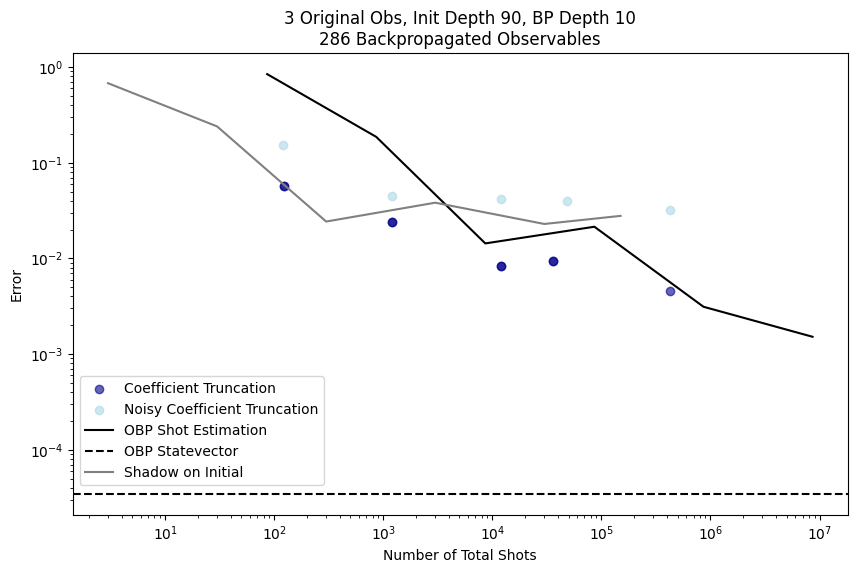

In [3]:
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data2'))
noisy_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_noisy'))

coef_df = pd.read_pickle(f'{data_path}/coef-trunc_init90_bp10_obs3.pkl')
noisy_coef_df = pd.read_pickle(f'{noisy_data_path}/coef-trunc_init90_bp10_obs3.pkl')

# pauli_df = pd.read_pickle(f'{data_path}/pauli-trunc7_init90_bp5_obs9.pkl')
obp_df = pd.read_pickle(f'{data_path}/obp_bp10_obs3.pkl')
shad_df = pd.read_pickle(f'{data_path}/shad_res_3.pkl')

obp_df['num_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.paulis))
obp_df['num_qwc_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.group_commuting(qubit_wise=True)))
obp_df['num_total_shots'] = obp_df['num_qwc_bp_obs'] * obp_df['obp_shots']

obs_num = 3
coef_df['obs_group'] = coef_df.index // obs_num
noisy_coef_df['obs_group'] = noisy_coef_df.index // obs_num

obp_df['obs_group'] = obp_df.index // obs_num
shad_df['obs_group'] = shad_df.index // obs_num
# pauli_df['obs_group'] = pauli_df.index // obs_num

gb1 = coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb_noisy = noisy_coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

# gb2 = pauli_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

gb_obp = obp_df.groupby('obs_group').agg({'num_total_shots': 'mean', 'abs_bp_error_shots': 'mean'}).reset_index()

gb_shad = shad_df.groupby('num_meas').agg({'abs_shad_error': 'mean'}).reset_index()

plt.figure(figsize=(10, 6))

plt.scatter(x=gb1['num_meas'], y=gb1['abs_total_error'], label='Coefficient Truncation', alpha=0.6, color='darkblue')
plt.scatter(x=gb_noisy['num_meas'], y=gb_noisy['abs_total_error'], label='Noisy Coefficient Truncation', alpha=0.6, color='lightblue')

# plt.scatter(x=gb2['num_meas'], y=gb2['abs_total_error'], label='Pauli Weight Truncation (7)', alpha=0.6, color='lightblue')

sns.lineplot(data=gb_obp, x='num_total_shots', y='abs_bp_error_shots', label='OBP Shot Estimation', color='black')
plt.axhline(y=obp_df['abs_bp_error_state'].mean(), color='black', linestyle='--', label='OBP Statevector')
sns.lineplot(data=gb_shad, x='num_meas', y='abs_shad_error', label='Shadow on Initial', color='gray')

plt.xscale('log')
plt.yscale('log')
plt.title(f'{obs_num} Original Obs, Init Depth 90, BP Depth 10\n{int(math.ceil(obp_df["num_bp_obs"].mean()))} Backpropagated Observables')
plt.xlabel('Number of Total Shots')
plt.ylabel('Error')

plt.legend(loc='lower left', bbox_to_anchor=(0, 0.05))

print(obp_df['num_qwc_bp_obs'].mean())

y_hline = gb1['abs_total_error'].min()
y_min = gb1[gb1['abs_total_error'] == y_hline]['num_meas'].values[0]
diff = gb_obp['abs_bp_error_shots'] - y_hline
crossings = diff.shift(-1) * diff < 0
for idx in gb_obp.index[crossings]:
    x0 = gb_obp.loc[idx, 'num_total_shots']
    y0 = gb_obp.loc[idx, 'abs_bp_error_shots']
    x1 = gb_obp.loc[idx + 1, 'num_total_shots']
    y1 = gb_obp.loc[idx + 1, 'abs_bp_error_shots']
    # Linear interpolation
    if y1 != y0:
        x_intersect = x0 + (y_hline - y0) * (x1 - x0) / (y1 - y0)
        print(f"Intersection at num_total_shots ≈ {x_intersect:.2f}")
        print(f"OBP-Shadow improvement is {x_intersect / y_min:.2f} times the minimum number of measurements for the coefficient truncation method.")

82.0
Intersection at num_total_shots ≈ 744827.65
OBP-Shadow improvement is 8.37 times the minimum number of measurements for the coefficient truncation method.


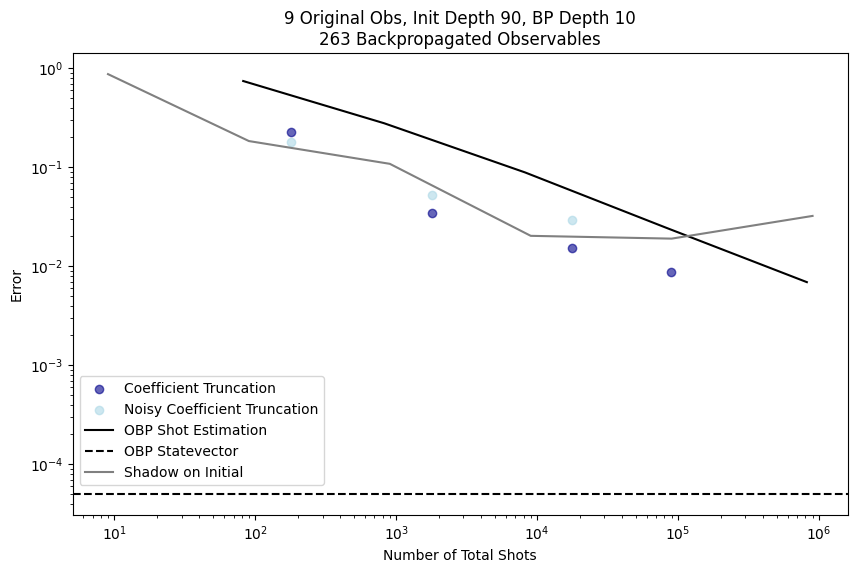

In [2]:
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data3'))
noisy_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_noisy'))

coef_df = pd.read_pickle(f'{data_path}/coef-trunc_init90_bp10_obs9.pkl')
noisy_coef_df = pd.read_pickle(f'{noisy_data_path}/coef-trunc_init90_bp10_obs9.pkl')

# pauli_df = pd.read_pickle(f'{data_path}/pauli-trunc7_init90_bp5_obs9.pkl')
obp_df = pd.read_pickle(f'{data_path}/obp_bp10_obs9.pkl')
shad_df = pd.read_pickle(f'{data_path}/shad_res_9.pkl')

obp_df['num_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.paulis))
obp_df['num_qwc_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.group_commuting(qubit_wise=True)))
obp_df['num_total_shots'] = obp_df['num_qwc_bp_obs'] * obp_df['obp_shots']

obs_num = 9
coef_df['obs_group'] = coef_df.index // obs_num
noisy_coef_df['obs_group'] = noisy_coef_df.index // obs_num

obp_df['obs_group'] = obp_df.index // obs_num
shad_df['obs_group'] = shad_df.index // obs_num
# pauli_df['obs_group'] = pauli_df.index // obs_num

gb1 = coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb_noisy = noisy_coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

# gb2 = pauli_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

gb_obp = obp_df.groupby('obs_group').agg({'num_total_shots': 'mean', 'abs_bp_error_shots': 'mean'}).reset_index()

gb_shad = shad_df.groupby('num_meas').agg({'abs_shad_error': 'mean'}).reset_index()

plt.figure(figsize=(10, 6))

plt.scatter(x=gb1['num_meas'], y=gb1['abs_total_error'], label='Coefficient Truncation', alpha=0.6, color='darkblue')
plt.scatter(x=gb_noisy['num_meas'], y=gb_noisy['abs_total_error'], label='Noisy Coefficient Truncation', alpha=0.6, color='lightblue')

# plt.scatter(x=gb2['num_meas'], y=gb2['abs_total_error'], label='Pauli Weight Truncation (7)', alpha=0.6, color='lightblue')

sns.lineplot(data=gb_obp, x='num_total_shots', y='abs_bp_error_shots', label='OBP Shot Estimation', color='black')
plt.axhline(y=obp_df['abs_bp_error_state'].mean(), color='black', linestyle='--', label='OBP Statevector')
sns.lineplot(data=gb_shad, x='num_meas', y='abs_shad_error', label='Shadow on Initial', color='gray')

plt.xscale('log')
plt.yscale('log')
plt.title(f'{obs_num} Original Obs, Init Depth 90, BP Depth 10\n{int(math.ceil(obp_df["num_bp_obs"].mean()))} Backpropagated Observables')
plt.xlabel('Number of Total Shots')
plt.ylabel('Error')

plt.legend(loc='lower left', bbox_to_anchor=(0, 0.05))

print(obp_df['num_qwc_bp_obs'].mean())

y_hline = gb1['abs_total_error'].min()
y_min = gb1[gb1['abs_total_error'] == y_hline]['num_meas'].values[0]
diff = gb_obp['abs_bp_error_shots'] - y_hline
crossings = diff.shift(-1) * diff < 0
for idx in gb_obp.index[crossings]:
    x0 = gb_obp.loc[idx, 'num_total_shots']
    y0 = gb_obp.loc[idx, 'abs_bp_error_shots']
    x1 = gb_obp.loc[idx + 1, 'num_total_shots']
    y1 = gb_obp.loc[idx + 1, 'abs_bp_error_shots']
    # Linear interpolation
    if y1 != y0:
        x_intersect = x0 + (y_hline - y0) * (x1 - x0) / (y1 - y0)
        print(f"Intersection at num_total_shots ≈ {x_intersect:.2f}")
        print(f"OBP-Shadow improvement is {x_intersect / y_min:.2f} times the minimum number of measurements for the coefficient truncation method.")

154.0


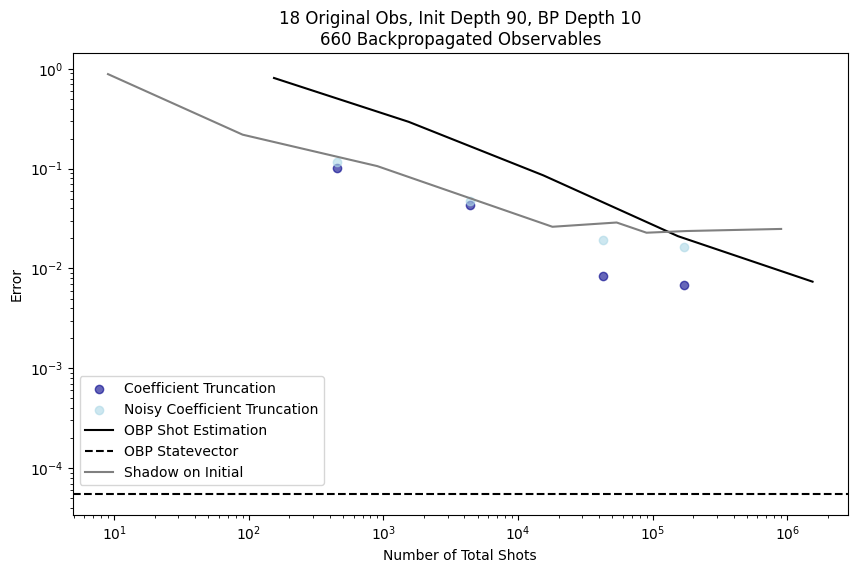

In [4]:
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data4'))
noisy_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_noisy'))

coef_df = pd.read_pickle(f'{data_path}/coef-trunc_init90_bp10_obs18.pkl')
noisy_coef_df = pd.read_pickle(f'{noisy_data_path}/coef-trunc_init90_bp10_obs18.pkl')

# pauli_df = pd.read_pickle(f'{data_path}/pauli-trunc7_init90_bp5_obs9.pkl')
obp_df = pd.read_pickle(f'{data_path}/obp_bp10_obs18.pkl')
shad_df = pd.read_pickle(f'{data_path}/shad_res_18.pkl')

obp_df['num_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.paulis))
obp_df['num_qwc_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.group_commuting(qubit_wise=True)))
obp_df['num_total_shots'] = obp_df['num_qwc_bp_obs'] * obp_df['obp_shots']

obs_num = 18
coef_df['obs_group'] = coef_df.index // obs_num
noisy_coef_df['obs_group'] = noisy_coef_df.index // obs_num

obp_df['obs_group'] = obp_df.index // obs_num
shad_df['obs_group'] = shad_df.index // obs_num
# pauli_df['obs_group'] = pauli_df.index // obs_num

gb1 = coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb_noisy = noisy_coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

# gb2 = pauli_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

gb_obp = obp_df.groupby('obs_group').agg({'num_total_shots': 'mean', 'abs_bp_error_shots': 'mean'}).reset_index()

gb_shad = shad_df.groupby('num_meas').agg({'abs_shad_error': 'mean'}).reset_index()

plt.figure(figsize=(10, 6))

plt.scatter(x=gb1['num_meas'], y=gb1['abs_total_error'], label='Coefficient Truncation', alpha=0.6, color='darkblue')
plt.scatter(x=gb_noisy['num_meas'], y=gb_noisy['abs_total_error'], label='Noisy Coefficient Truncation', alpha=0.6, color='lightblue')

# plt.scatter(x=gb2['num_meas'], y=gb2['abs_total_error'], label='Pauli Weight Truncation (7)', alpha=0.6, color='lightblue')

sns.lineplot(data=gb_obp, x='num_total_shots', y='abs_bp_error_shots', label='OBP Shot Estimation', color='black')
plt.axhline(y=obp_df['abs_bp_error_state'].mean(), color='black', linestyle='--', label='OBP Statevector')
sns.lineplot(data=gb_shad, x='num_meas', y='abs_shad_error', label='Shadow on Initial', color='gray')

plt.xscale('log')
plt.yscale('log')
plt.title(f'{obs_num} Original Obs, Init Depth 90, BP Depth 10\n{int(math.ceil(obp_df["num_bp_obs"].mean()))} Backpropagated Observables')
plt.xlabel('Number of Total Shots')
plt.ylabel('Error')

plt.legend(loc='lower left', bbox_to_anchor=(0, 0.05))

print(obp_df['num_qwc_bp_obs'].mean())

y_hline = gb1['abs_total_error'].min()
y_min = gb1[gb1['abs_total_error'] == y_hline]['num_meas'].values[0]
diff = gb_obp['abs_bp_error_shots'] - y_hline
crossings = diff.shift(-1) * diff < 0
for idx in gb_obp.index[crossings]:
    x0 = gb_obp.loc[idx, 'num_total_shots']
    y0 = gb_obp.loc[idx, 'abs_bp_error_shots']
    x1 = gb_obp.loc[idx + 1, 'num_total_shots']
    y1 = gb_obp.loc[idx + 1, 'abs_bp_error_shots']
    # Linear interpolation
    if y1 != y0:
        x_intersect = x0 + (y_hline - y0) * (x1 - x0) / (y1 - y0)
        print(f"Intersection at num_total_shots ≈ {x_intersect:.2f}")
        print(f"OBP-Shadow improvement is {x_intersect / y_min:.2f} times the minimum number of measurements for the coefficient truncation method.")

In [ ]:
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data5'))
noisy_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_noisy'))

coef_df = pd.read_pickle(f'{data_path}/coef-trunc_init90_bp10_obs36.pkl')
noisy_coef_df = pd.read_pickle(f'{noisy_data_path}/coef-trunc_init90_bp10_obs36.pkl')

# pauli_df = pd.read_pickle(f'{data_path}/pauli-trunc7_init90_bp5_obs9.pkl')
obp_df = pd.read_pickle(f'{data_path}/obp_bp10_obs36.pkl')
shad_df = pd.read_pickle(f'{data_path}/shad_res_36.pkl')

obp_df['num_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.paulis))
obp_df['num_qwc_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.group_commuting(qubit_wise=True)))
obp_df['num_total_shots'] = obp_df['num_qwc_bp_obs'] * obp_df['obp_shots']

obs_num = 36
coef_df['obs_group'] = coef_df.index // obs_num
noisy_coef_df['obs_group'] = noisy_coef_df.index // obs_num

obp_df['obs_group'] = obp_df.index // obs_num
shad_df['obs_group'] = shad_df.index // obs_num
# pauli_df['obs_group'] = pauli_df.index // obs_num

gb1 = coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb_noisy = noisy_coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

# gb2 = pauli_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

gb_obp = obp_df.groupby('obs_group').agg({'num_total_shots': 'mean', 'abs_bp_error_shots': 'mean'}).reset_index()

gb_shad = shad_df.groupby('num_meas').agg({'abs_shad_error': 'mean'}).reset_index()

plt.figure(figsize=(10, 6))

plt.scatter(x=gb1['num_meas'], y=gb1['abs_total_error'], label='Coefficient Truncation', alpha=0.6, color='darkblue')
plt.scatter(x=gb_noisy['num_meas'], y=gb_noisy['abs_total_error'], label='Noisy Coefficient Truncation', alpha=0.6, color='lightblue')

# plt.scatter(x=gb2['num_meas'], y=gb2['abs_total_error'], label='Pauli Weight Truncation (7)', alpha=0.6, color='lightblue')

sns.lineplot(data=gb_obp, x='num_total_shots', y='abs_bp_error_shots', label='OBP Shot Estimation', color='black')
plt.axhline(y=obp_df['abs_bp_error_state'].mean(), color='black', linestyle='--', label='OBP Statevector')
sns.lineplot(data=gb_shad, x='num_meas', y='abs_shad_error', label='Shadow on Initial', color='gray')

plt.xscale('log')
plt.yscale('log')
plt.title(f'{obs_num} Original Obs, Init Depth 90, BP Depth 10\n{int(math.ceil(obp_df["num_bp_obs"].mean()))} Backpropagated Observables')
plt.xlabel('Number of Total Shots')
plt.ylabel('Error')

plt.legend(loc='lower left', bbox_to_anchor=(0, 0.05))

print(obp_df['num_qwc_bp_obs'].mean())

y_hline = gb1['abs_total_error'].min()
y_min = gb1[gb1['abs_total_error'] == y_hline]['num_meas'].values[0]
diff = gb_obp['abs_bp_error_shots'] - y_hline
crossings = diff.shift(-1) * diff < 0
for idx in gb_obp.index[crossings]:
    x0 = gb_obp.loc[idx, 'num_total_shots']
    y0 = gb_obp.loc[idx, 'abs_bp_error_shots']
    x1 = gb_obp.loc[idx + 1, 'num_total_shots']
    y1 = gb_obp.loc[idx + 1, 'abs_bp_error_shots']
    # Linear interpolation
    if y1 != y0:
        x_intersect = x0 + (y_hline - y0) * (x1 - x0) / (y1 - y0)
        print(f"Intersection at num_total_shots ≈ {x_intersect:.2f}")
        print(f"OBP-Shadow improvement is {x_intersect / y_min:.2f} times the minimum number of measurements for the coefficient truncation method.")